# Assignment 1

## Vizualizarea Datelor

Pentru început, vom importa bibliotecile necesare și vom încărca fișierul `MergeConflictsDataset.csv` care conține setul nostru de date. De asemenea, vom vizualiza setul de date pentru a înțelege mai bine structura acestuia.

In [33]:
import sys
assert sys.version_info >= (3, 5)
import sklearn
assert sklearn.__version__ >= "0.20"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from IPython.display import display

%matplotlib inline

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('MergeConflictsDataset.csv', sep=';')

display(df.head())

Saving MergeConflictsDataset.csv to MergeConflictsDataset (1).csv


,commit,parent1,parent2,ancestor,is pr,added lines,deleted lines,devs parent1,devs parent2,time,nr files,added files,deleted files,renamed files,copied files,modified files,nr commits1,nr commits2,density1,density2,fix,bug,feature,improve,document,refactor,update,add,remove,use,delete,change,messages_min,messages_max,messages_mean,messages_median,conflict
0,efc0bcd1d6199448c323549fdc45310750b48c85,fb9f2a65cabba5a924b89a45793914066471b2ab,5ee7c7c750e9ecffaea12f97d5b05b2445e7c007,fb9f2a65cabba5a924b89a45793914066471b2ab,1,5,0,0,1,23,0,0,0,0,0,4,0,5,0,0,0,0,0,0,0,0,3,0,0,0,0,0,20,65,35.40000,20.0,0
1,287b9b838b6b6b212ef538aa537aef76110ee111,72fd7d81c9c7e28af8740f5a1b210a803290383d,fb9f2a65cabba5a924b89a45793914066471b2ab,a18c1088c892f1e6ed4b7d541e68b2e4b039a42e,0,1166,11267,1,2,371,3,7,199,2,0,177,2,47,2,13,1,0,0,0,0,0,1,0,0,0,0,0,31,117,58.56383,53.5,1
2,e7478680c0db825239ea9628967728c8577bb5c2,36977963caa2896ad9a4a92b2bdcd85189beccb1,bc230857adc3a9763bc7d89793d826463c857c00,36977963caa2896ad9a4a92b2bdcd85189beccb1,1,0,0,0,1,22,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,18,18.00000,18.0,0
3,0c65b30a8fd3a7db40163fcb9b0004cb7487c0ff,419e6d2d9fb91f2d9cdbdd1161a6c7ecc329363f,877c43f8242b88447d0234400c6e9b5c7586b558,fe29962932a8e34f0c3ac5cd795cd40090c9fabd,1,0,0,2,1,24,1,0,0,0,0,1,5,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,22,63,38.80000,31.0,0
4,419e6d2d9fb91f2d9cdbdd1161a6c7ecc329363f,7899f565d3461ed287e61662c8d399aafcac9e42,5e68e04e310c4f57a19d4cfa6be1e0ba3a8801d6,236b85af833398e0f07d08b7d7a25734d8c1b11d,0,0,0,1,2,2,1,0,0,0,0,1,1,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,31,56,43.50000,43.5,1


In [34]:
display(df.describe())

,is pr,added lines,deleted lines,devs parent1,devs parent2,time,nr files,added files,deleted files,renamed files,copied files,modified files,nr commits1,nr commits2,density1,density2,fix,bug,feature,improve,document,refactor,update,add,remove,use,delete,change,messages_min,messages_max,messages_mean,messages_median,conflict
count,26973.000000,2.697300e+04,2.697300e+04,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.0,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000,26973.000000
mean,0.777741,4.255746e+02,2.504278e+02,4.656175,1.911801,240.714159,0.752048,2.431061,1.396545,0.970229,0.0,8.169614,19.264301,5.419679,5.021985,1.279205,4.347644,0.470322,0.161606,0.350054,0.450376,0.178178,2.135469,4.316205,0.955437,1.338857,0.096281,1.007860,51.391280,104.662551,69.455646,68.021095,0.054425
std,0.415772,8.887706e+03,1.027916e+04,12.230444,6.534316,908.382038,10.620490,67.840678,90.614277,64.245155,0.0,74.931372,56.461614,25.426160,15.209514,5.721774,12.434022,1.983746,0.880704,2.502933,1.825317,0.783933,6.751948,12.924317,3.203307,4.269666,0.541916,6.033535,34.560112,89.471017,40.057823,39.385369,0.226858
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000e+00,1.000000e+00,0.000000,1.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,47.000000,41.000000,40.000000,0.000000
50%,1.000000,1.100000e+01,2.000000e+00,1.000000,1.000000,36.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,2.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,46.000000,88.000000,66.391304,65.000000,0.000000
75%,1.000000,7.500000e+01,1.500000e+01,3.000000,1.000000,139.000000,0.000000,0.000000,0.000000,0.000000,0.0,3.000000,10.000000,2.000000,2.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,67.000000,131.000000,91.714286,90.000000,0.000000
max,1.000000,1.140945e+06,1.140456e+06,158.000000,182.000000,21513.000000,1152.000000,10404.000000,10396.000000,10398.000000,0.0,4289.000000,499.000000,489.000000,253.000000,227.000000,242.000000,89.000000,36.000000,136.000000,34.000000,14.000000,161.000000,176.000000,48.000000,78.000000,16.000000,312.000000,1326.000000,1326.000000,1326.000000,1326.000000,1.000000


Vizualizăm coloanele și tipul de date folosit pentru acestea.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26973 entries, 0 to 26972
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   commit           26973 non-null  object 
 1   parent1          26973 non-null  object 
 2   parent2          26973 non-null  object 
 3   ancestor         26972 non-null  object 
 4   is pr            26973 non-null  int64  
 5   added lines      26973 non-null  int64  
 6   deleted lines    26973 non-null  int64  
 7   devs parent1     26973 non-null  int64  
 8   devs parent2     26973 non-null  int64  
 9   time             26973 non-null  int64  
 10  nr files         26973 non-null  int64  
 11  added files      26973 non-null  int64  
 12  deleted files    26973 non-null  int64  
 13  renamed files    26973 non-null  int64  
 14  copied files     26973 non-null  int64  
 15  modified files   26973 non-null  int64  
 16  nr commits1      26973 non-null  int64  
 17  nr commits2 

## Analiza Datelor
Este esențial să înțelegem cum sunt distribuite clasele în problema noastră. Graficul de mai jos ilustrează proporția dintre cazurile fără conflict (0) și cele cu conflict (1).

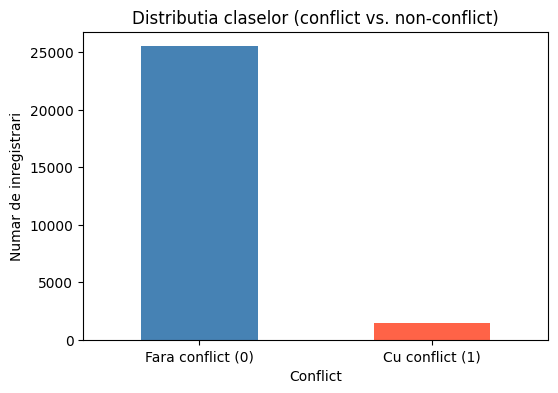

In [36]:
plt.figure(figsize=(6, 4))
df['conflict'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distributia claselor (conflict vs. non-conflict)')
plt.xlabel('Conflict')
plt.ylabel('Numar de inregistrari')
plt.xticks([0, 1], ['Fara conflict (0)', 'Cu conflict (1)'], rotation=0)
plt.show()

Am generat histograme pentru a observa distribuția fiecărei variabile. Observăm că multe atribute prezintă o distribuție puternic asimetrică, cu valori extreme (outliers).

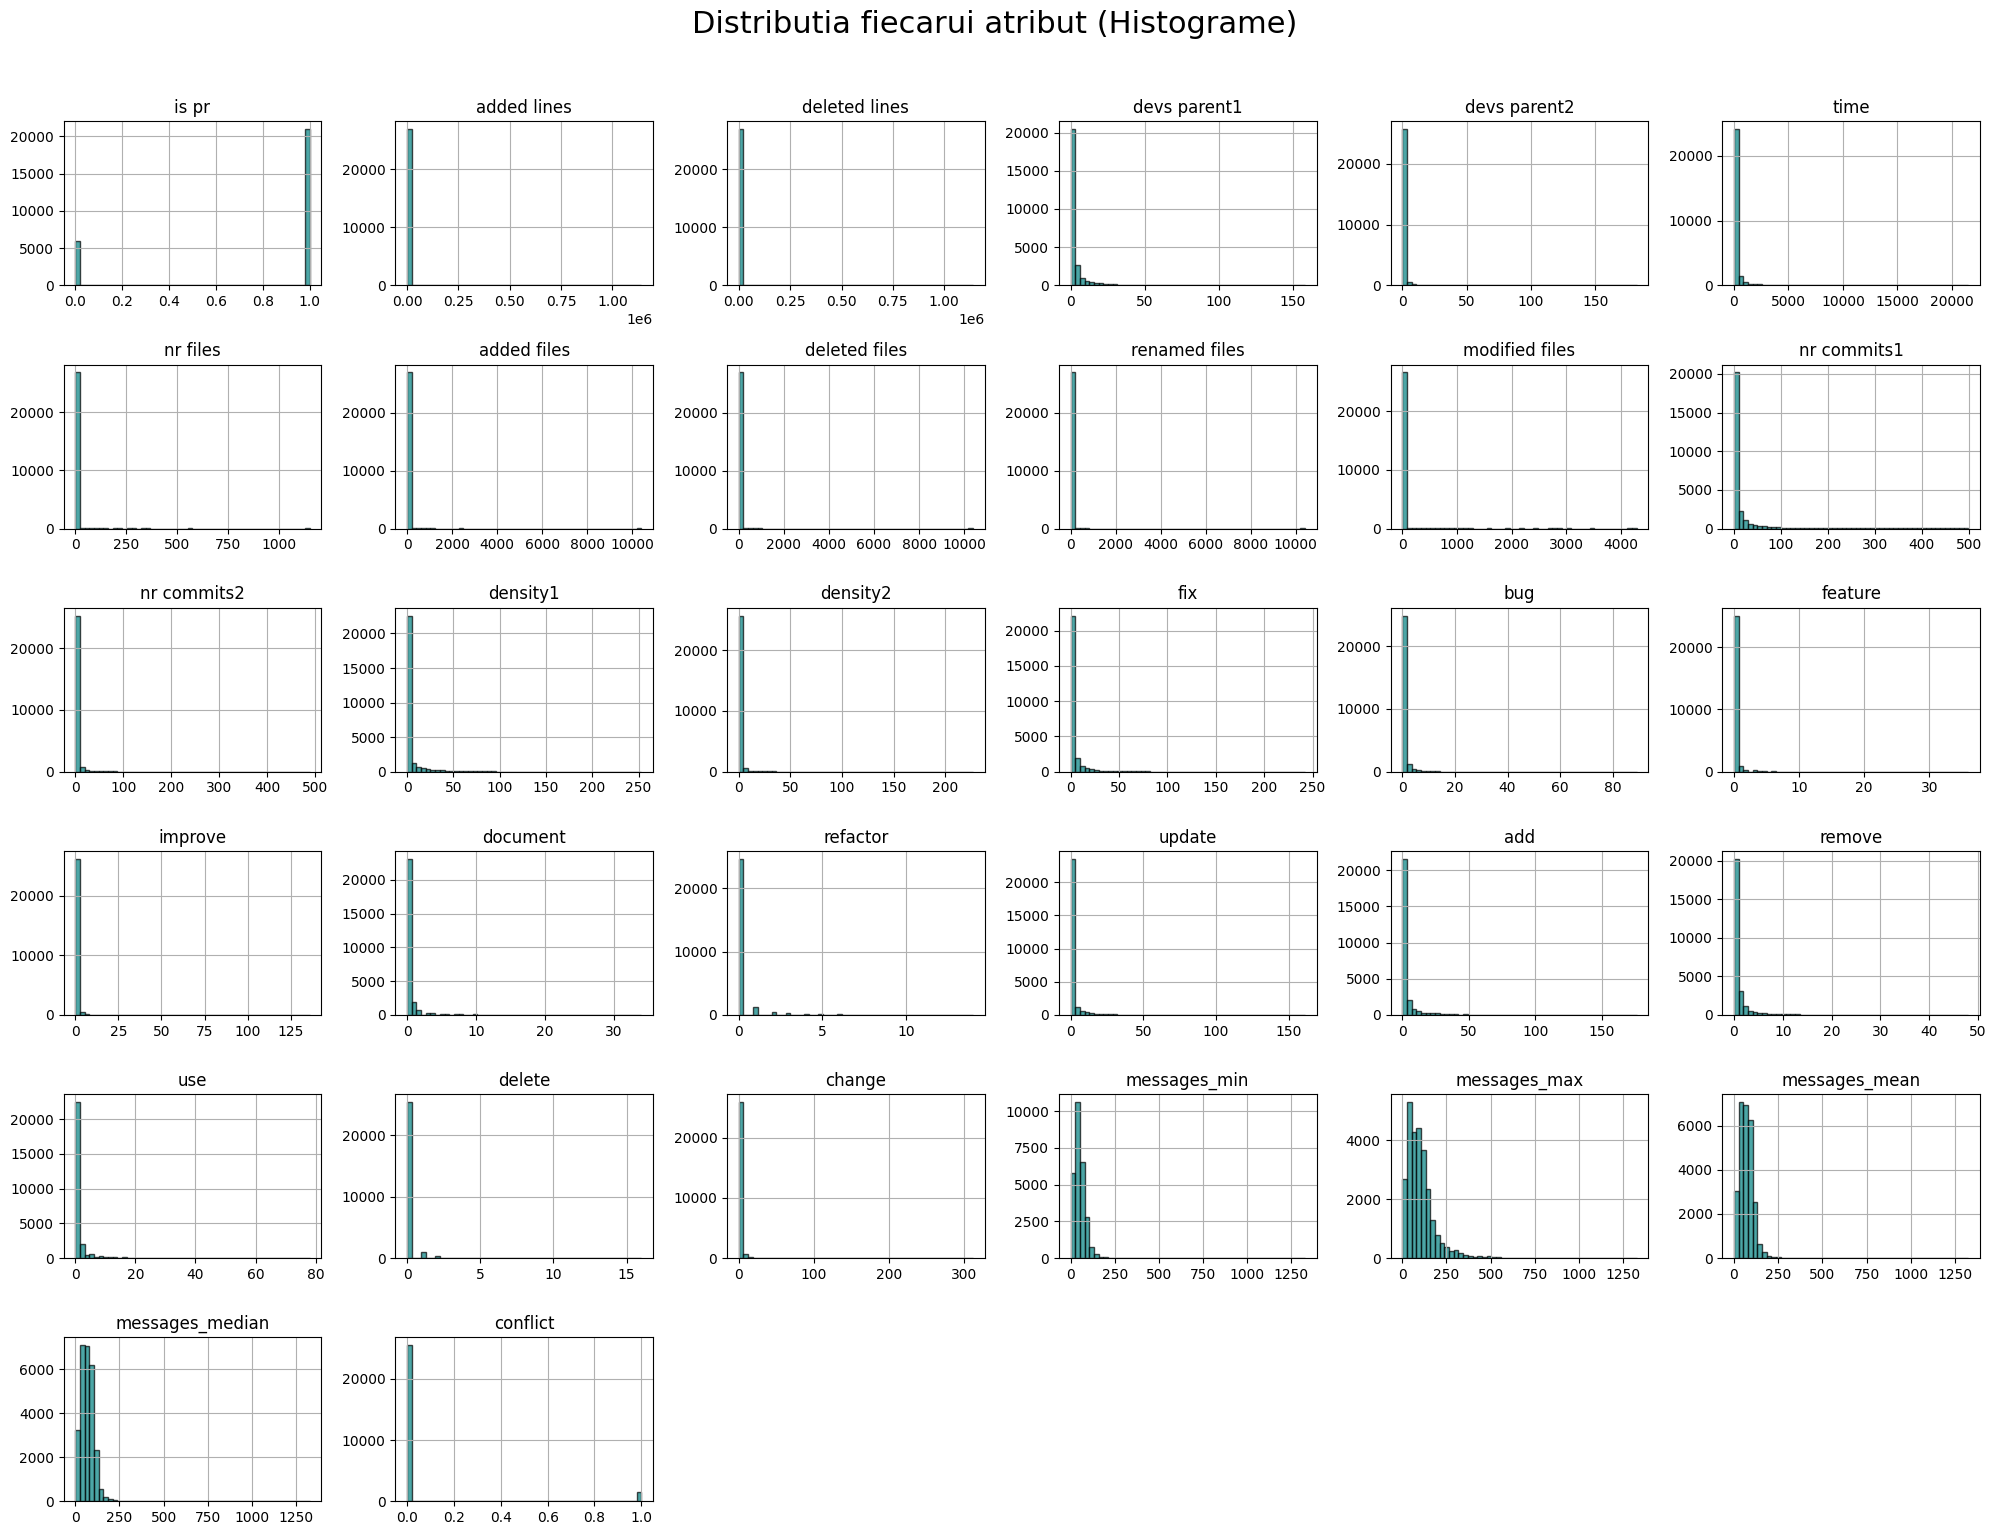

In [37]:
df_numeric = df.drop(columns=['commit', 'parent1', 'parent2', 'ancestor', 'copied files'])

df_numeric.hist(bins=50, figsize=(20, 15), color='teal', edgecolor='black', alpha=0.7)
plt.suptitle('Distributia fiecarui atribut (Histograme)', fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

## Identificarea corelațiilor

De asemenea, am calculat Matricea de Corelație Pearson pentru a investiga relațiile liniare dintre caracteristici și variabila țintă (`conflict`). Rezultatele indică existența unor corelații moderate, cea mai ridicată valoare fiind de aproximativ 0.30 (pentru atributul `nr commits2`).

Deși aceste valori sunt mai mari decât în alte seturi de date similare, ele rămân totuși sub pragul unei corelații liniare puternice. Aceasta este o concluzie valoroasă: ne indică faptul că, deși anumiți factori influențează vizibil apariția unui conflict, relația nu este una simplă, de tip cauză-efect liniară. Acest lucru justifică utilizarea unor modele avansate, bazate pe arbori de decizie (precum Random Forest), care pot capta interacțiunile complexe și non-liniare dintre acești predictori mult mai bine decât un simplu model liniar.

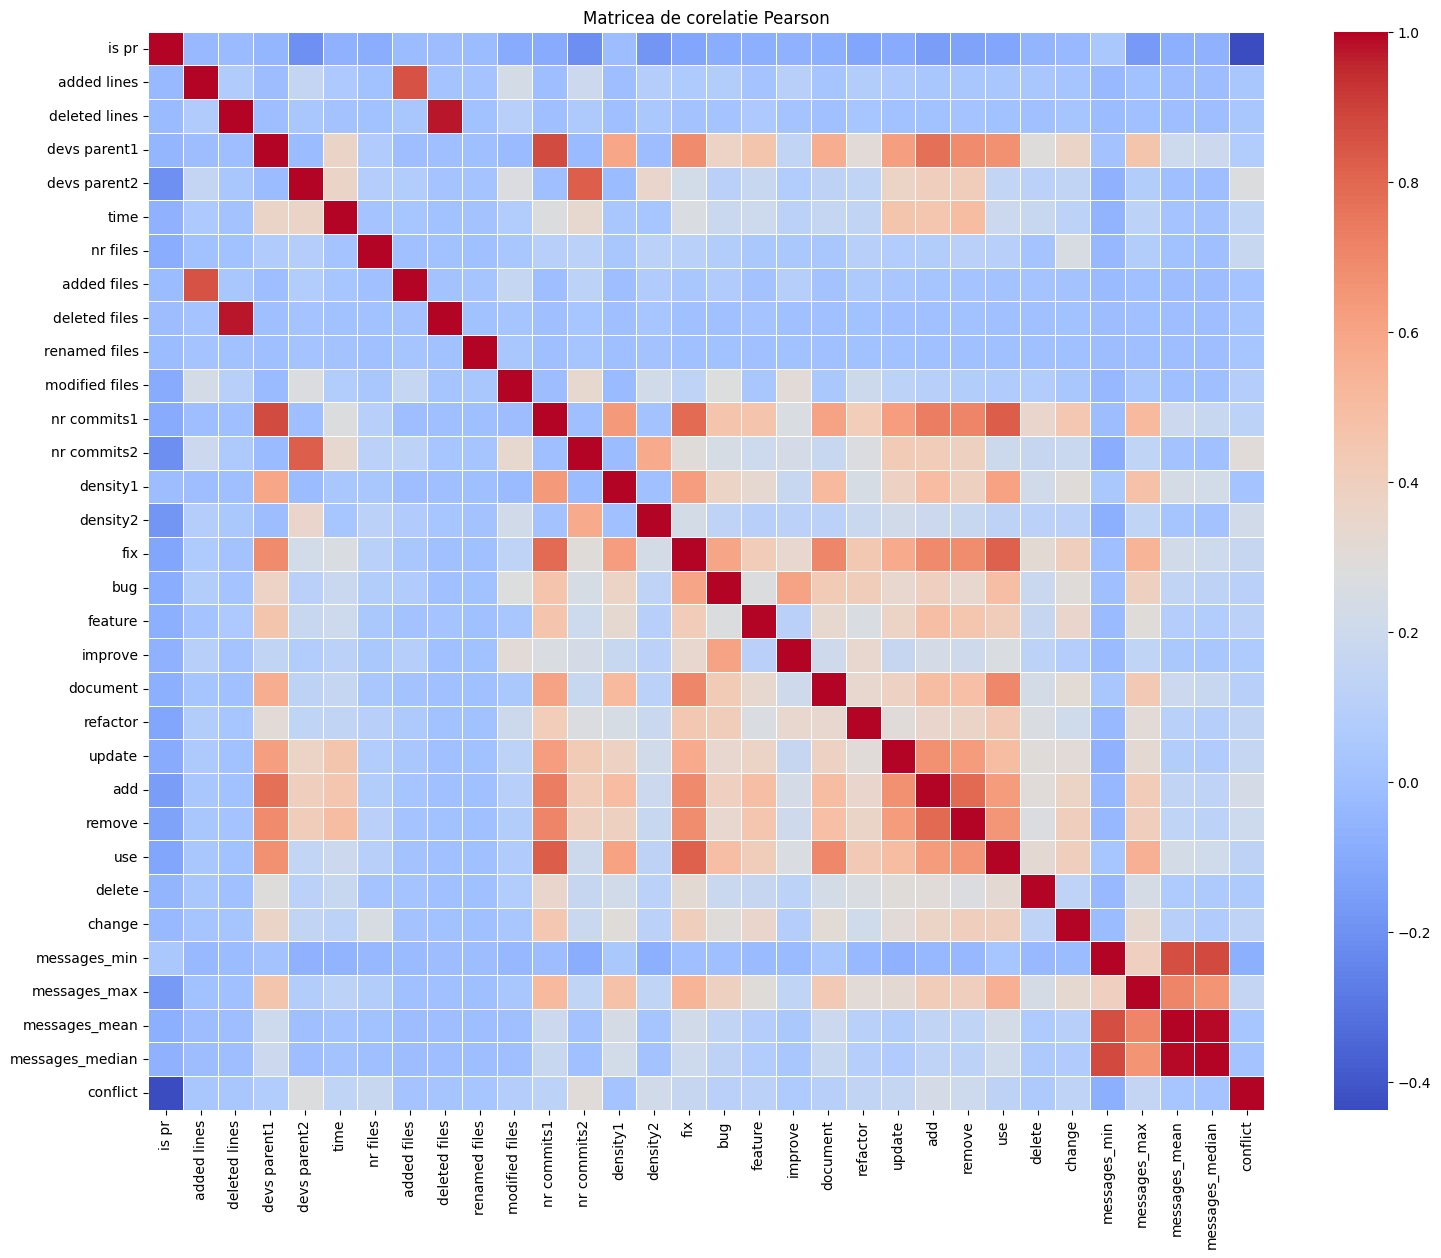

In [38]:
corr_matrix = df_numeric.corr(numeric_only=True)
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matricea de corelatie Pearson')
plt.show()

In [39]:
corelatii_target = pd.DataFrame(corr_matrix['conflict'].sort_values(ascending=False))
display(corelatii_target.style.background_gradient(cmap='coolwarm'))

,conflict
conflict,1.000000
nr commits2,0.303397
devs parent2,0.274583
add,0.235729
density2,0.219509
remove,0.202772
nr files,0.172194
fix,0.164832
update,0.158182
messages_max,0.153547


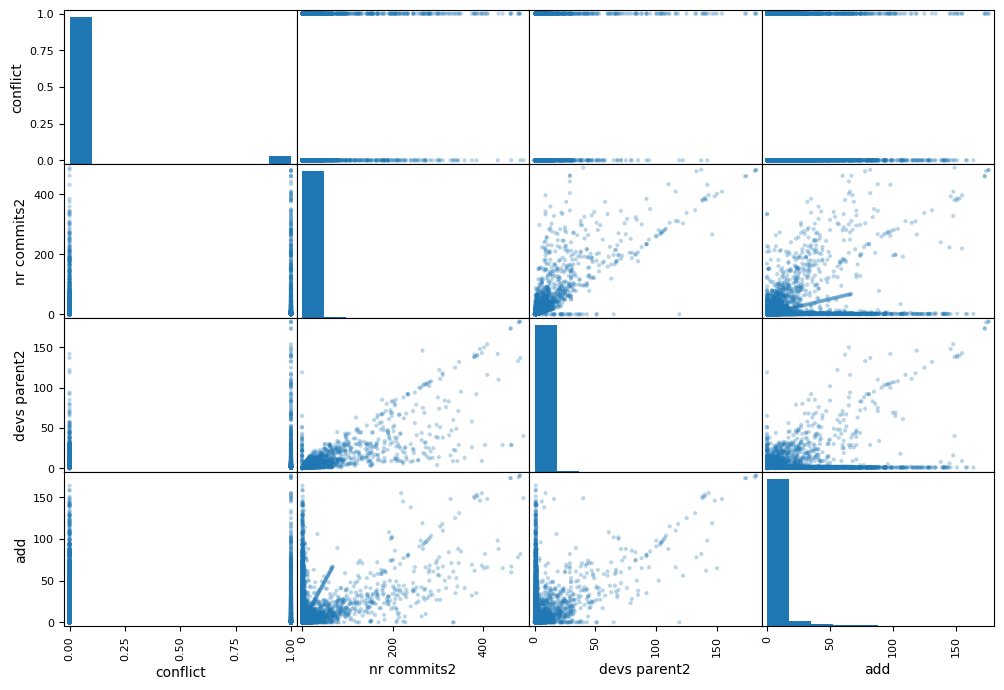

In [40]:
from pandas.plotting import scatter_matrix

df_clean = df_numeric.copy()

attributes = ["conflict", "nr commits2", "devs parent2", "add"]

scatter_matrix(df_clean[attributes], figsize=(12, 8), alpha=0.3)
plt.show()

## Selecția și combinarea atributelor

În etapa de selecție și combinare, am optimizat setul de date prin eliminarea identificatorilor text și a coloanelor constante (ex: copied files), care nu aduceau valoare statistică. Ulterior, am generat atribute sintetice precum total_impact, p2_activity_score și new_features_work pentru a capta interacțiunile complexe dintre volumul de cod și intensitatea colaborării pe branch-uri. Succesul acestui pas este confirmat de matricea de corelație, unde noile variabile au devenit predictori de top, oferind modelelor o bază informațională mult mai bogată decât datele brute inițiale.

In [41]:
df_clean['total_lines_changed'] = df_clean['added lines'] + df_clean['deleted lines']
df_clean['global_collab_intensity'] = (df_clean['devs parent1'] + df_clean['devs parent2']) * (df_clean['nr commits1'] + df_clean['nr commits2'])
df_clean['lines_per_file'] = df_clean['total_lines_changed'] / (df_clean['nr files'])
df_clean['change_velocity'] = df_clean['total_lines_changed'] / (df_clean['time'])
df_clean['maintenance_work'] = df_clean['fix'] + df_clean['bug']
df_clean['new_features_work'] = df_clean['feature'] + df_clean['add']
df_clean['p2_pressure_index'] = df_clean['density2'] * df_clean['devs parent2']
df_clean['msg_consistency'] = df_clean['messages_mean'] / (df_clean['messages_max'])
df_clean['branch_activity_diff'] = abs(df_clean['nr commits1'] - df_clean['nr commits2'])
df_clean['pr_impact_mitigation'] = df_clean['is pr'] * df_clean['total_lines_changed']

new_corr = df_clean.corr()['conflict'].sort_values(ascending=False)
display(new_corr.head(15))

,conflict
conflict,1.000000
nr commits2,0.303397
devs parent2,0.274583
add,0.235729
new_features_work,0.235508
density2,0.219509
remove,0.202772
branch_activity_diff,0.193426
p2_pressure_index,0.173845
nr files,0.172194


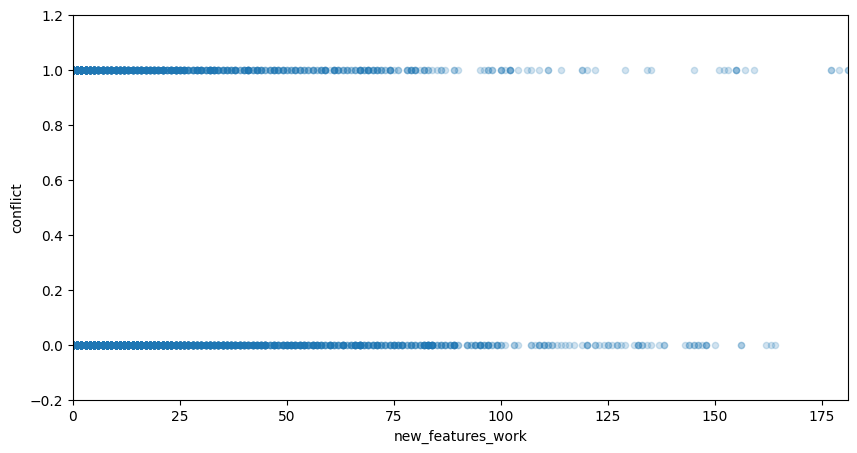

In [42]:
df_clean.plot(kind="scatter", x="new_features_work", y="conflict",
             alpha=0.2, figsize=(10, 5))

plt.axis([0, df_clean["new_features_work"].max(), -0.2, 1.2])

plt.xlabel("new_features_work")
plt.ylabel("conflict")
plt.show()

## Curățarea și pregătirea datelor

Înainte de a antrena modelele, datele trebuie curățate și pregătite:
* **Eliminarea coloanelor irelevante:** Am eliminat coloanele pur textuale sau de identificare (`commit`, `parent1`, `parent2`, `ancestor`), deoarece acestea nu au valoare predictivă generalizabilă și ar introduce "zgomot" în model. De asemenea, am eliminat duplicatele și coloanele constante(`copied_files`).
* **Tratarea valorilor lipsă:** Am completat eventualele valori lipsă folosind **mediana** fiecărei coloane. Am ales mediana în detrimentul mediei deoarece, așa cum am văzut la histograme, datele noastre au multe valori extreme care ar distorsiona media.
* **Împărțirea datelor (Train/Test Split):** Am separat variabilele independente (`X`) de etichetă (`y`). Am împărțit datele folosind o proporție de 80% pentru antrenament și 20% pentru testare. Este crucial faptul că am folosit parametrul `stratify=y` pentru a garanta că proporția cazurilor de conflict rămâne identică în ambele seturi.

In [43]:
# eliminam duplicate
df_clean = df_clean.drop_duplicates()

#eliminam coloane constante
constant_cols = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]
df_clean = df_clean.drop(columns=constant_cols)

In [44]:
X = df_clean.drop(columns=['conflict'])
y = df_clean['conflict']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Selecția metricii de performanță

În cadrul acestui proiect, alegerea metricii este dictată de dezechilibrul semnificativ al claselor (numărul de „non-conflicte” este mult mai mare decât cel al „conflictelor”). Într-un astfel de scenariu, Acuratețea este o metrică înșelătoare: un model care ar prezice întotdeauna absența unui conflict ar obține un scor ridicat, deși ar eșua complet în a identifica problemele reale. Din acest motiv, am selectat Scorul F1 (F1-Score) ca metrică principală de evaluare. Acesta reprezintă media armonică între Precizie (capacitatea de a nu genera alarme false) și Recall (capacitatea de a detecta toate conflictele existente). Scorul F1 este calculat prin formula:$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$Utilizarea Scorului F1 ne permite să evaluăm capacitatea modelului de a gestiona corect clasa minoritară (conflictele), oferind un echilibru între evitarea întreruperilor inutile ale dezvoltatorilor prin alerte false și minimizarea riscului de a trece cu vederea merge conflicts critice.

## Pipeline

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

num_attribs = list(X_train.columns)
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
    ])

X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print(f"Set de antrenare pregătit: {X_train_prepared.shape}")
print(f"Set de test pregătit: {X_test_prepared.shape}")

Set de antrenare pregătit: (21204, 41)
Set de test pregătit: (5302, 41)


## Explorarea și selecția modelului

## Logistic Regression

Am început explorarea cu Logistic Regression pentru a stabili un prag de performanță inițial, folosind setarea class_weight='balanced' pentru a compensa dezechilibrul claselor din setul de date. Rezultatele obținute arată un scor F1 pe antrenare de 0.4039 și un scor de Cross-Validation de 0.4078, ceea ce indică faptul că modelul este extrem de stabil și nu suferă de overfitting, deoarece generalizează la fel de bine pe date noi cum o face pe cele de antrenament. Totuși, valoarea modestă a scorului de aproximativ 41% demonstrează un fenomen clar de underfitting, sugerând că o graniță de decizie liniară este prea simplă pentru a capta complexitatea cauzelor conflictelor de tip merge. Prin urmare, deși modelul este robust, rezultatele confirmă necesitatea de a experimenta cu algoritmi mai sofisticați, cum ar fi Random Forest, care pot identifica tipare neliniare mai profunde în date.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score

# evaluarea modelului de baza
log_reg_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_base.fit(X_train_prepared, y_train)

# calcularea scorului F1
y_train_pred_base = log_reg_base.predict(X_train_prepared)
f1_train_base = f1_score(y_train, y_train_pred_base)

# calcularea scorului F1 cu cross-validation
cv_scores_base = cross_val_score(log_reg_base, X_train_prepared, y_train, scoring='f1', cv=5)
f1_cv_base = cv_scores_base.mean()

print(f"Scor F1 Training: {f1_train_base:.4f}")
print(f"Scor F1 Cross-Validation: {f1_cv_base:.4f}")

Scor F1 Training: 0.4039
Scor F1 Cross-Validation: 0.4078


## Grid Search

Pentru a optimiza modelul, am implementat tehnica GridSearchCV, care a testat sistematic mai multe combinații între parametrul de regularizare C și algoritmii de calcul de tip solver. În urma acestei căutări, am identificat setările optime ca fiind C: 100 și solver: 'liblinear', obținând un scor F1 de 0.4172. Faptul că modelul a ales cea mai mare valoare disponibilă pentru C (care înseamnă o regularizare foarte slabă) ne indică faptul că algoritmul a încercat să reducă pe cât posibil constrângerile pentru a se mula mai bine pe complexitatea datelor. Deși am obținut o îmbunătățire față de modelul de bază (de la 0.4078 la 0.4172), creșterea este una marginală, ceea ce demonstrează că am atins limita superioară de performanță a unui model liniar pentru această problemă. Analiza tabelară a rezultatelor ne-a permis să observăm cum performanța a crescut constant odată cu mărirea valorii lui C, confirmând încă o dată că modelul suferă de fenomenul de underfitting.

In [47]:
param_grid_log = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100],
     'solver': ['liblinear', 'lbfgs']}
]

grid_search_log = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid_log,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search_log.fit(X_train_prepared, y_train)
best_log_reg = grid_search_log.best_estimator_

print(f"Cele mai bune setari gasite: {grid_search_log.best_params_}")
print(f"Scor F1 Cross-Validation (Grid Search): {grid_search_log.best_score_:.4f}")

results_df = pd.DataFrame(grid_search_log.cv_results_)
display_cols = ['mean_test_score', 'param_C', 'param_solver']

clean_df = results_df[display_cols]
clean_df = clean_df.sort_values(by='mean_test_score', ascending=False)
display(clean_df)

Cele mai bune setari gasite: {'C': 100, 'solver': 'liblinear'}
Scor F1 Cross-Validation (Grid Search): 0.4172


,mean_test_score,param_C,param_solver
10,0.417182,100.000,liblinear
8,0.415247,10.000,liblinear
11,0.415001,100.000,lbfgs
9,0.414388,10.000,lbfgs
7,0.407826,1.000,lbfgs
6,0.407802,1.000,liblinear
5,0.395470,0.100,lbfgs
4,0.394366,0.100,liblinear
3,0.390402,0.010,lbfgs
2,0.389038,0.010,liblinear


## Randomized Search

Prin RandomizedSearchCV, am extins căutarea hiperparametrilor dincolo de o listă fixă de valori, explorând un spațiu continuu pentru parametrul de regularizare C. În urma acestui proces, am obținut o valoare optimă de aproximativ 21.36 și am identificat solver-ul lbfgs ca fiind cel mai eficient, cu un scor F1 de 0.4144.

Rezultatul este foarte apropiat de cel obținut prin Grid Search, ceea ce ne confirmă faptul că am atins un plafon de performanță pentru Logistic Regression pe acest set de date. Practic, oricât de precis am regla acești parametri, arhitectura liniară a modelului nu îi permite să depășească pragul de 41%. Această concluzie este una valoroasă, deoarece ne demonstrează că am optimizat modelul la potențialul său maxim, iar pentru rezultate mai bune este necesară trecerea la un algoritm mai complex, precum Random Forest, capabil să surprindă relații neliniare între date.

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist_log = {
    'C': loguniform(1e-2, 1e2),
    'solver': ['liblinear', 'lbfgs']
}

rnd_search_log = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_distributions=param_dist_log,
    n_iter=15,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rnd_search_log.fit(X_train_prepared, y_train)
best_log_reg_rnd = rnd_search_log.best_estimator_

print(f"Cele mai bune setari gasite: {rnd_search_log.best_params_}")
print(f"Scor F1 Cross-Validation (Randomized Search): {rnd_search_log.best_score_:.4f}")

results_rnd_df = pd.DataFrame(rnd_search_log.cv_results_)

display_cols_rnd = ['mean_test_score', 'param_C', 'param_solver']
clean_rnd_df = results_rnd_df[display_cols_rnd]
clean_rnd_df = clean_rnd_df.sort_values(by='mean_test_score', ascending=False)

display(clean_rnd_df)

Cele mai bune setari gasite: {'C': np.float64(21.368329072358772), 'solver': 'lbfgs'}
Scor F1 Cross-Validation (Randomized Search): 0.4144


,mean_test_score,param_C,param_solver
8,0.414425,21.368329,lbfgs
6,0.413606,6.796578,lbfgs
11,0.412697,2.796486,liblinear
2,0.412434,2.481041,liblinear
13,0.408718,1.256315,liblinear
3,0.404515,0.607199,liblinear
12,0.403235,0.534294,liblinear
0,0.399512,0.314891,liblinear
5,0.397779,0.216189,lbfgs
10,0.394115,0.054152,lbfgs


Rezultatele detaliate pentru Logistic Regression arată un model cu o senzitivitate (recall) extrem de ridicată, reușind să identifice 1141 de conflicte și să rateze doar 25 (False Negatives). Totuși, acest echilibru vine cu un cost ridicat: un număr mare de alarme false (3214 False Positives). Această configurație indică faptul că modelul liniar, deși forțat prin parametrul class_weight='balanced' să prindă clasa minoritară, nu este destul de precis pentru a distinge clar între cazuri, „alegând” să raporteze aproape orice situație suspectă ca fiind un conflict. Acest comportament explică scorul F1 de 0.41 și justifică trecerea la un model mai inteligent, precum Random Forest, care ar trebui să mențină rata mare de detecție, dar să reducă semnificativ numărul alarmelor false.

Confusion Matrix:
[[16824  3214]
 [   25  1141]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     20038
           1       0.26      0.98      0.41      1166

    accuracy                           0.85     21204
   macro avg       0.63      0.91      0.66     21204
weighted avg       0.96      0.85      0.88     21204

True Negatives (TN): 16824
False Positives (FP): 3214
False Negatives (FN): 25
True Positives (TP): 1141


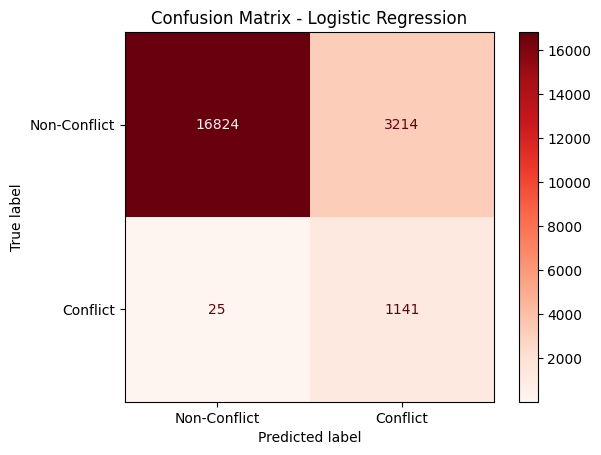

In [49]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_train_pred_cv = cross_val_predict(best_log_reg_rnd, X_train_prepared, y_train, cv=5)
cm_log = confusion_matrix(y_train, y_train_pred_cv)

print("Confusion Matrix:")
print(cm_log)
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred_cv))

tn, fp, fn, tp = cm_log.ravel()

print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Non-Conflict', 'Conflict'])
disp.plot(cmap=plt.cm.Reds)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Random Forest

Rezultatele obținute cu modelul Random Forest de bază evidențiază o îmbunătățire semnificativă a performanței, dar și o provocare clară de modelare. Scorul F1 de 0.9991 pe setul de antrenament, comparat cu cel de 0.6326 obținut prin Cross-Validation, indică un fenomen puternic de overfitting. Aceasta înseamnă că modelul a memorat particularitățile setului de antrenament în loc să învețe doar reguli generale. Cu toate acestea, faptul că scorul de validare (0.63) este considerabil mai mare decât cel al Logistic Regression (0.41) demonstrează că un model non-liniar este mult mai adecvat pentru acest set de date. Pasul următor constă în optimizarea hiperparametrilor pentru a 'simplifica' arborii de decizie și a forța modelul să generalizeze mai bine pe date noi.

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_base.fit(X_train_prepared, y_train)

# scorul la training
y_train_pred_rf = rf_base.predict(X_train_prepared)
f1_train_rf = f1_score(y_train, y_train_pred_rf)

# scor obtinut prin cross-validation
cv_scores_rf = cross_val_score(rf_base, X_train_prepared, y_train, scoring='f1', cv=5)
f1_cv_rf = cv_scores_rf.mean()

print(f"Scor F1 Training: {f1_train_rf:.4f}")
print(f"Scor F1 Cross-Validation: {f1_cv_rf:.4f}")

Scor F1 Training: 0.9991
Scor F1 Cross-Validation: 0.6326


## Randomized Search

Deoarece modelul de bază a prezentat un fenomen clar de overfitting, am apelat la RandomizedSearchCV pentru a găsi un echilibru între capacitatea de învățare și generalizare. Spre deosebire de Grid Search, această metodă explorează rapid spațiul de căutare prin testarea unui număr fix de combinații aleatorii, fiind mult mai eficientă pentru algoritmi complecși precum Random Forest.

Această etapă de căutare a reușit să îmbunătățească modelul, ridicând scorul F1 de la 0.63 la 0.7044. Am demonstrat astfel că, prin constrângerea structurii arborilor, modelul devine mult mai abil în a detecta conflictele reale.

In [51]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(100, 500),      # nr. de arbori
    'max_depth': randint(10, 30),           # limitarea adancimii
    'min_samples_split': randint(2, 20),    # cate exemple trebuie sa fie intr-un nod ca sa se divida
    'min_samples_leaf': randint(1, 10),     # cate exemple trebuie sa ramana intr-o frunza
    'max_features': ['sqrt', 'log2']        # folosim radicalul si logaritmul (sunt cele mai bune pentru random forest)
}

rnd_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

rnd_search_rf.fit(X_train_prepared, y_train)

print(f"Cele mai bune setari: {rnd_search_rf.best_params_}")
print(f"Scor F1 (Randomized Search): {rnd_search_rf.best_score_:.4f}")

Cele mai bune setari: {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 478}
Scor F1 (Randomized Search): 0.7044


## Grid Search

După ce RandomizedSearchCV a identificat regiunea optimă a hiperparametrilor (zona din jurul adâncimii de 17 și a unui număr de aproximativ 480 de arbori), am trecut la etapa de GridSearchCV. Această metodă este una exhaustivă: ea testează absolut fiecare combinație posibilă din grila definită, asigurându-ne că nu ratăm nicio variație care ar putea aduce un plus de performanță.

În urma acestui proces, am obținut modelul final cu un scor F1 de 0.7079.

In [52]:
param_grid_rf = {
    'max_depth': [16, 17, 18],
    'n_estimators': [460, 478],
    'min_samples_leaf': [2, 3],
    'min_samples_split': [2, 3]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search_rf.fit(X_train_prepared, y_train)
best_rf_grid = grid_search_rf.best_estimator_

print(f"Cele mai bune setari: {grid_search_rf.best_params_}")
print(f"Scor F1 (Grid Search): {grid_search_rf.best_score_:.4f}")

Cele mai bune setari: {'max_depth': 16, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 478}
Scor F1 (Grid Search): 0.7079


Matricea de confuzie pentru modelul Random Forest optimizat confirmă faptul că am reușit să atingem un echilibru performant între detecție și precizie, demonstrând o superioritate netă față de modelele anterioare. Cu un număr de 1028 de True Positives (TP), modelul identifică marea majoritate a conflictelor reale, atingând un Recall de 0.88, în timp ce reducerea drastică a False Positives (FP) la doar 745 (față de cele peste 3200 de la Logistic Regression) a ridicat Precision la 0.58, oferind astfel avertismente mult mai credibile și mai puțin invazive pentru dezvoltatori. Deși există un mic compromis prin ratarea a 138 de conflicte (False Negatives), scorul F1 de 0.70 validează succesul acestui model ca fiind un instrument robust, capabil să gestioneze eficient datele dezechilibrate și să ofere predicții de încredere în scenarii reale de lucru.


Confusion Matrix:
[[19293   745]
 [  138  1028]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     20038
           1       0.58      0.88      0.70      1166

    accuracy                           0.96     21204
   macro avg       0.79      0.92      0.84     21204
weighted avg       0.97      0.96      0.96     21204


True Negatives (TN): 19293
False Positives (FP): 745
False Negatives (FN): 138
True Positives (TP): 1028


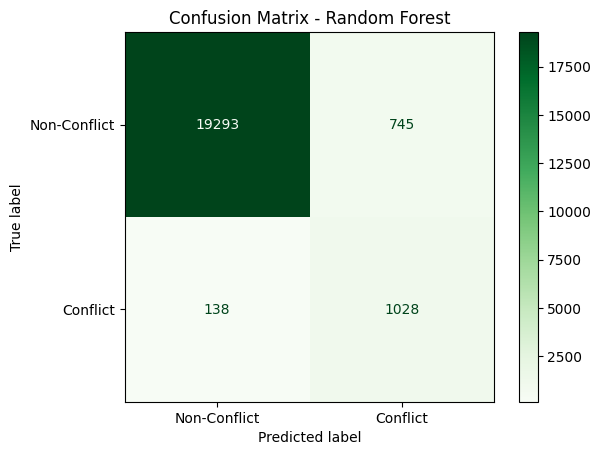

In [53]:
y_train_rf_cv = cross_val_predict(best_rf_grid, X_train_prepared, y_train, cv=5)

cm_rf = confusion_matrix(y_train, y_train_rf_cv)

print(f"\nConfusion Matrix:")
print(cm_rf)
print("\nClassification Report:")
print(classification_report(y_train, y_train_rf_cv))

tn, fp, fn, tp = cm_rf.ravel()

print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Non-Conflict', 'Conflict'])
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Hist Gradient Boosting

Rezultatele inițiale pentru HistGradientBoosting sunt extrem de promițătoare. Comparând scorul F1 de pe setul de antrenament (0.7264) cu cel obținut prin cross-validation (0.6844), observăm o consistență ridicată și o absență aproape totală a fenomenului de overfitting. Această stabilitate se datorează modului în care algoritmul folosește histogramele și arborii simpli (weak learners) pentru a aproxima datele. Faptul că modelul pornește de la o performanță de bază superioară algoritmului Random Forest sugerează că arhitectura de tip Boosting este mai eficientă în capturarea relațiilor complexe din acest set de date.

In [54]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_base = HistGradientBoostingClassifier(class_weight='balanced', max_iter=100, random_state=42)
hgb_base.fit(X_train_prepared, y_train)

y_train_pred_hgb = hgb_base.predict(X_train_prepared)
f1_train_hgb = f1_score(y_train, y_train_pred_hgb)

cv_scores_hgb = cross_val_score(hgb_base, X_train_prepared, y_train, scoring='f1', cv=5)
f1_cv_hgb = cv_scores_hgb.mean()

print(f"Scor F1 Training: {f1_train_hgb:.4f}")
print(f"Scor F1 Cross-Validation: {f1_cv_hgb:.4f}")

Scor F1 Training: 0.7264
Scor F1 Cross-Validation: 0.6844


## Randomized Search

Am folosit o căutare rapidă (RandomizedSearch) pentru a găsi automat cele mai bune setări ale modelului, astfel încât acesta să învețe eficient fără să piardă prea mult timp. Rezultatul de 0.6777 arată că am găsit un echilibru ideal: modelul este destul de „atent” să prindă conflictele complicate, dar și suficient de rapid și stabil pentru a funcționa bine pe date noi. Practic, am obținut o soluție mai performantă și mai sigură decât metodele standard, cu un efort minim de procesare.

In [55]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

hgb_model = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

param_dist_hgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 300, 500],
    'max_depth': [3, 5, 8],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [20, 50, 100],
    'l2_regularization': [0.1, 1.0, 10.0]
}

random_search_hgb = RandomizedSearchCV(
    hgb_model,
    param_distributions=param_dist_hgb,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search_hgb.fit(X_train_prepared, y_train)

print(f"Cele mai bune setari gasite: {random_search_hgb.best_params_}")
print(f"Scor F1 (Randomized Search): {random_search_hgb.best_score_:.4f}")

Cele mai bune setari gasite: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 500, 'max_depth': 8, 'learning_rate': 0.01, 'l2_regularization': 0.1}
Scor F1 (Randomized Search): 0.6777


Configurația finală a modelului HistGradientBoostingClassifier a fost selectată pentru a prioritiza stabilitatea în detrimentul complexității excesive. Prin reducerea adâncimii arborilor la 3 și impunerea unei limite de 100 de mostre pentru fiecare frunză, modelul este constrâns să ignore variațiile nesemnificative din date și să identifice doar tiparele structurale majore. Parametrul class_weight echilibrează importanța conflictelor în procesul de învățare, în timp ce regularizarea L2 și mecanismul early stopping previn memorarea zgomotului din setul de antrenament. Scorul F1 de 0.6777 reflectă o capacitate de generalizare solidă, demonstrând că algoritmul a atins un echilibru optim între precizie și capacitatea de detecție.

In [56]:
from sklearn.model_selection import StratifiedKFold

best_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    max_depth=3,
    max_leaf_nodes=15,
    min_samples_leaf=100,
    l2_regularization=5.0,
    class_weight='balanced',
    early_stopping=True,
    n_iter_no_change=15,
    random_state=42
)

best_model.fit(X_train_prepared, y_train)

print(f"Scor F1: {random_search_hgb.best_score_:.4f}")

Scor F1: 0.6777


Pentru a obține o estimare obiectivă a performanței pe date noi, am evaluat modelul final utilizând cross validation. Rezultatele demonstrează o capacitate de detecție remarcabilă, atingând un Recall de 0.98 pentru clasa conflictelor, ceea ce corespunde identificării corecte a 1144 de cazuri și ratării a doar 22. Deși modelul generează un număr semnificativ de false positives (1151), scorul F1 de 0.66 confirmă un echilibru robust, validând decizia de a prioritiza siguranța sistemului prin minimizarea riscului de a trece cu vederea conflicte reale.


Confusion Matrix
[[18887  1151]
 [   22  1144]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     20038
           1       0.50      0.98      0.66      1166

    accuracy                           0.94     21204
   macro avg       0.75      0.96      0.82     21204
weighted avg       0.97      0.94      0.95     21204


True Negatives (TN): 18887
False Positives (FP): 1151
False Negatives (FN): 22
True Positives (TP): 1144


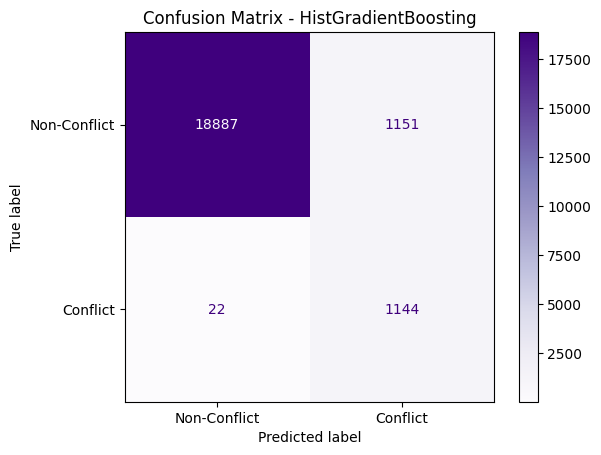

In [57]:
y_train_hgb_cv = cross_val_predict(best_model, X_train_prepared, y_train, cv=5)

cm_hgb = confusion_matrix(y_train, y_train_hgb_cv)

print(f"\nConfusion Matrix")
print(cm_hgb)
print("\nClassification Report:")
print(classification_report(y_train, y_train_hgb_cv))

tn, fp, fn, tp = cm_hgb.ravel()

print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_hgb, display_labels=['Non-Conflict', 'Conflict'])
disp.plot(cmap=plt.cm.Purples)
plt.title("Confusion Matrix - HistGradientBoosting")
plt.show()

In [58]:
!pip install shap

## Explainable AI

## SHAP (SHapley Additive exPlanations)

Analiza SHAP confirmă că absența unui Pull Request este unul dintre cei mai critici predictori pentru apariția conflictelor, validând matematic importanța procesului de code review. În graficul de tip summary, variabila num__is pr ocupă o poziție de top, unde lipsa unui PR (punctele albastre) împinge constant modelul spre o predicție de conflict, în timp ce existența acestuia (punctele roz) trage scorul în zona negativă, scăzând riscul. Graficul de dependență oferă un detaliu suplimentar esențial: atunci când nu există un PR, riscul de conflict explodează, efectul fiind amplificat de un număr mare de fișiere modificate (punctele roz din stânga-sus). Practic, modelul a învățat că un flux de lucru nestructurat, combinat cu un volum mare de schimbări, este rețeta sigură pentru probleme de integrare, recunoscând în Pull Request un veritabil „filtru de siguranță” care reduce probabilitatea erorilor înainte ca acestea să ajungă în ramura principală.

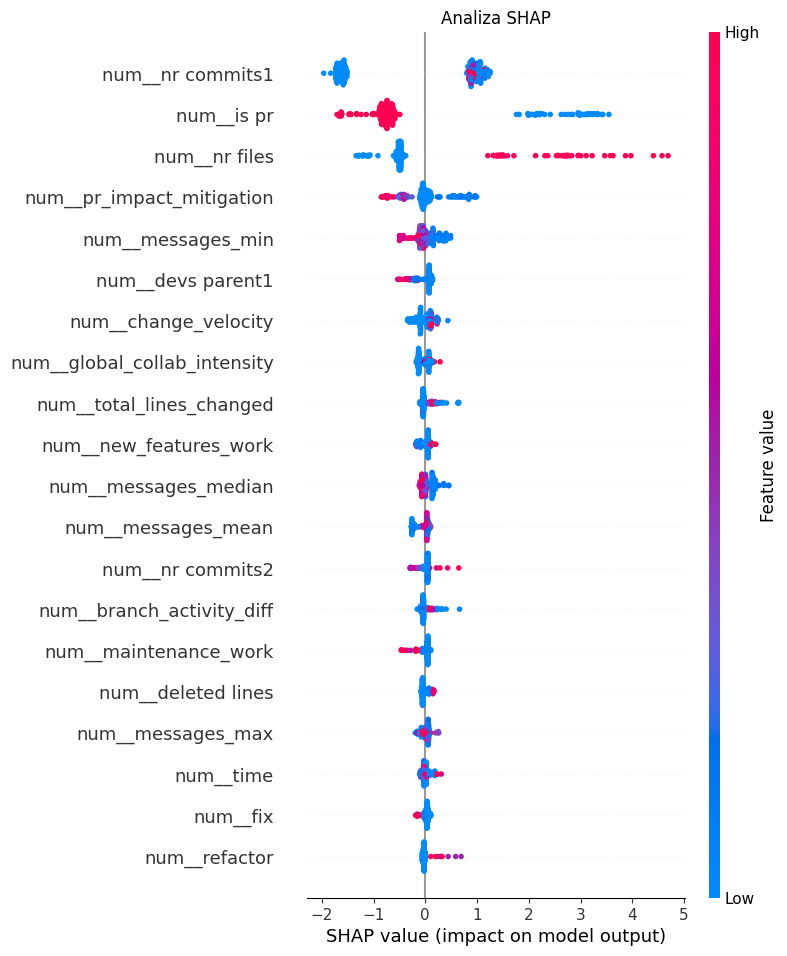

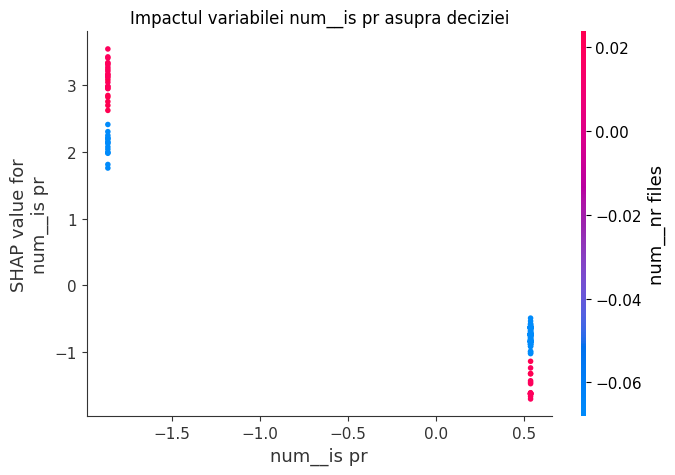

In [59]:
import shap

feature_names = list(full_pipeline.get_feature_names_out())

explainer = shap.TreeExplainer(best_model)
X_test_subset = X_test_prepared[:200]
shap_values = explainer.shap_values(X_test_subset)

shap.summary_plot(shap_values, X_test_subset, feature_names=feature_names, show=False)
plt.title("Analiza SHAP")
plt.show()

print("\n\n")

target_feature = "num__is pr"
shap.dependence_plot(target_feature, shap_values, X_test_subset, feature_names=feature_names, show=False)
plt.title(f"Impactul variabilei {target_feature} asupra deciziei")
plt.show()

## Alegerea modelului
Alegerea modelului `HistGradientBoostingClassifier` s-a bazat pe performanța sa ridicată în gestionarea datelor tabelare și pe capacitatea nativă de a procesa seturi de date mari prin tehnica de „binning” a histogramelor, care optimizează semnificativ timpul de antrenare și consumul de memorie. Un avantaj critic în contextul acestui proiect este suportul direct pentru parametrul `class_weight='balanced'`, o funcționalitate vitală pentru a corecta dezechilibrul masiv dintre clase și pentru a forța modelul să acorde importanța cuvenită conflictelor rare, dar critice.  Mai mult, acest algoritm este extrem de robust în prezența valorilor lipsă sau a zgomotului din date, oferind o generalizare superioară față de modelele tradiționale și transformându-l în alegerea ideală pentru un sistem de predicție a conflictelor care trebuie să fie atât rapid, cât și extrem de precis.

## Evaluarea modelului pe setul de testare

În această etapă finală, utilizăm cel mai bun model identificat pentru a face predicții pe setul de date de test. Evaluăm performanța folosind Scorul F1 și un Classification Report complet, deoarece acestea oferă o imagine clară asupra capacității modelului de a identifica corect conflictele (Recall) fără a genera prea multe alarme false (Precision), într-un context în care clasele sunt neechilibrate.

Evaluarea pe setul de test demonstrează că modelul identifică cu succes 98% din conflictele reale (Recall 0.98), îndeplinind astfel obiectivul principal de a preveni erorile de integrare a codului. Deși precizia de 0.51 arată că există și alarme false, această sensibilitate ridicată este necesară pentru a garanta că niciun merge conflict critic nu rămâne nedetectat. Scorul F1 de aproximativ 0.67, obținut pe date complet noi, confirmă faptul că algoritmul a extras reguli logice din procesul de dezvoltare și generalizează corect, asigurând o monitorizare eficientă a riscurilor tehnice.


In [60]:
final_model = best_model

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_f1 = f1_score(y_test, final_predictions)
print(f"Scorul F1 pe setul de test: {final_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Scorul F1 pe setul de test: 0.6690

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      5011
           1       0.51      0.98      0.67       291

    accuracy                           0.95      5302
   macro avg       0.75      0.96      0.82      5302
weighted avg       0.97      0.95      0.95      5302



Calcularea intervalului de încredere oferă o măsură a fiabilității performanței pe date noi. Rezultatul obținut, [0.9406, 0.9527], indică o probabilitate de 95% ca acuratețea modelului să se situeze între 94% și 95% în condiții reale de utilizare. Deoarece acest interval este foarte îngust, putem concluziona că modelul este stabil și că rezultatele obținute sunt constante, nefiind influențate de variații aleatorii ale setului de test.

In [61]:
from scipy import stats

confidence = 0.95
accuracy = (final_predictions == y_test).mean()
n = len(y_test)

z_score = stats.norm.ppf((1 + confidence) / 2)
margin_of_error = z_score * np.sqrt((accuracy * (1 - accuracy)) / n)

lower_bound = accuracy - margin_of_error
upper_bound = accuracy + margin_of_error

print(f"Intervalul de incredere (95%): [{lower_bound:.4f}, {upper_bound:.4f}]")

Intervalul de incredere (95%): [0.9406, 0.9527]


## Curba ROC (Receiver Operating Characteristic) și AUC (Area Under the Curve)

Curba ROC vizualizează capacitatea modelului de a face distincția între conflicte și integrări sigure la diferite praguri de decizie, punând în balanță rata succeselor și cea a alertelor false. Scorul AUC de 0.98, fiind extrem de aproape de valoarea maximă, confirmă o performanță superioară, indicând o probabilitate de 98% ca algoritmul să identifice corect un risc de conflict în raport cu o situație fără probleme. Distanța mare dintre curba albastră și linia diagonală punctată demonstrează că modelul este mult mai eficient decât o selecție aleatorie, asigurând o separare aproape optimă a claselor și o fiabilitate ridicată în procesul de predicție.

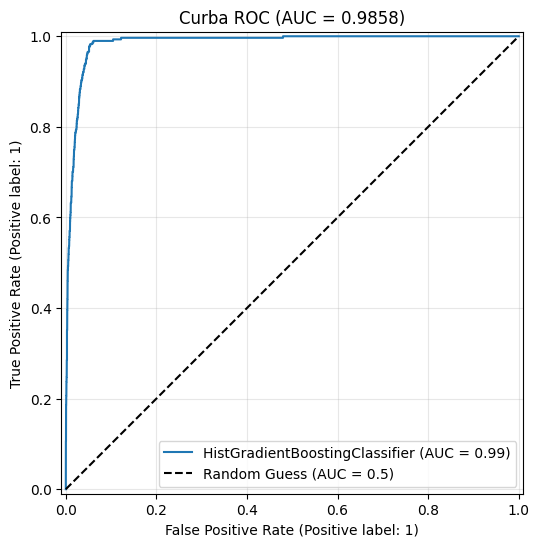

In [62]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_score = final_model.predict_proba(X_test_prepared)[:, 1]
auc_value = roc_auc_score(y_test, y_score)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(final_model, X_test_prepared, y_test, ax=ax)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.title(f"Curba ROC (AUC = {auc_value:.4f})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Curba Precision-Recall (PR Curve)

Curba Precision-Recall evaluează performanța modelului concentrându-se strict pe succesul în detectarea clasei minoritare, adică a conflictelor de tip merge, fiind mult mai informativă decât curba ROC pentru seturile de date neechilibrate. Scorul de precizie medie (AP) de 0.80 indică o capacitate ridicată a algoritmului de a identifica majoritatea conflictelor reale menținând în același timp un număr scăzut de alarme false. Acest grafic confirmă stabilitatea modelului, arătând că acesta păstrează o precizie solidă pe măsură ce pragul de senzitivitate (recall) crește, ceea ce asigură o monitorizare eficientă și credibilă a riscurilor în procesul de dezvoltare software.

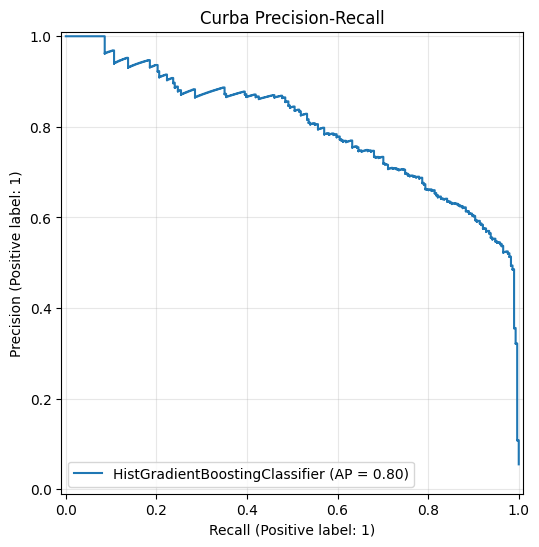

In [63]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_estimator(final_model, X_test_prepared, y_test, ax=ax)
plt.title("Curba Precision-Recall")
plt.grid(alpha=0.3)
plt.show()

## Matricea de Confuzie Normalizată

Matricea de confuzie normalizată oferă o perspectivă clară asupra ratei de succes pentru fiecare categorie, eliminând distorsiunile cauzate de volumul diferit de date dintre clase. Rezultatele arată că modelul identifică corect 98% din conflictele reale (Recall) și 94% din integrările sigure, demonstrând o capacitate de generalizare foarte bună pe ambele dimensiuni. Acest nivel ridicat de detecție confirmă eficiența algoritmului în semnalarea riscurilor tehnice, reducând rata conflictelor nedeclarate la doar 2%, ceea ce asigură o monitorizare riguroasă a procesului de integrare.

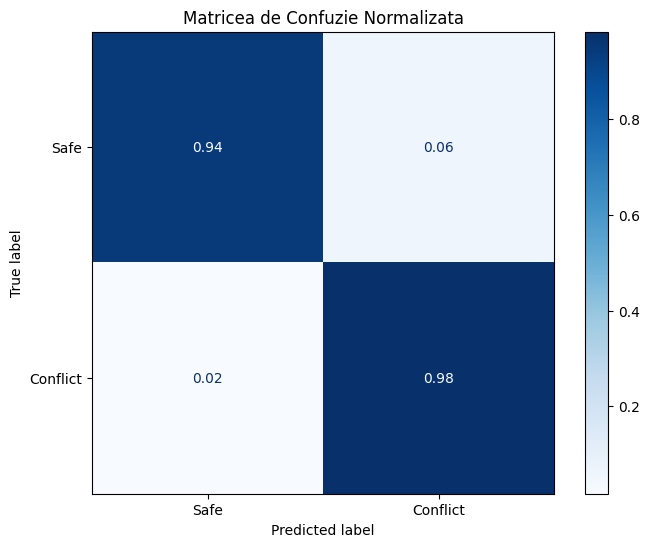

In [64]:
cm_normalized = confusion_matrix(y_test, final_predictions, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Safe', 'Conflict'])
disp.plot(cmap='Blues', values_format='.2f', ax=ax)
plt.title("Matricea de Confuzie Normalizata")
plt.show()

## Analiza Erorilor (Error Distribution Plot)

Analiza distribuției erorilor evidențiază faptul că modelul întâmpină cele mai mari dificultăți în clasificarea operațiunilor cu un volum redus de fișiere, în special în cazul modificărilor care implică un singur fișier. Se observă că aproape toate conflictele ratate (False Negatives) apar atunci când este modificat un singur fișier, ceea ce indică o tendință a algoritmului de a subestima riscurile de integrare atunci când numărul de fișiere implicate este minim. În același timp, alarmele false (False Positives) sunt concentrate tot în zona modificărilor restrânse, de 1-2 fișiere, dar prezintă numeroase valori extreme ce ajung până la 16 fișiere, sugerând că modelul devine uneori excesiv de sensibil pe măsură ce complexitatea crește. Această discrepanță indică faptul că numărul de fișiere, deși este un predictor important, nu oferă suficient context pentru a distinge între suprapunerile critice de cod și integrările sigure în cazul modificărilor izolate, semnalând necesitatea unor atribute suplimentare despre conținutul schimbărilor.

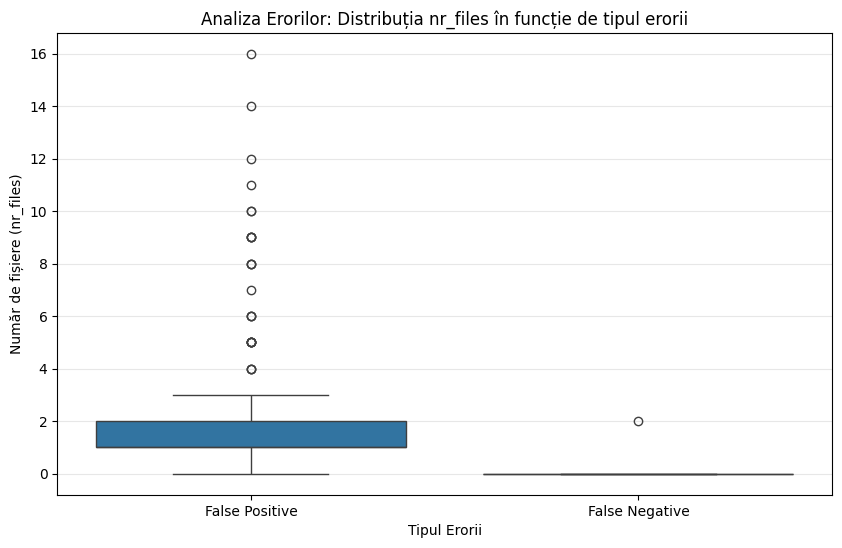

In [65]:
analysis_df = X_test.copy()
analysis_df['realitate'] = y_test.values
analysis_df['predictie'] = final_predictions

analysis_df['tip_eroare'] = 'Corect'
analysis_df.loc[(analysis_df['realitate'] == 0) & (analysis_df['predictie'] == 1), 'tip_eroare'] = 'False Positive'
analysis_df.loc[(analysis_df['realitate'] == 1) & (analysis_df['predictie'] == 0), 'tip_eroare'] = 'False Negative'

errors_only = analysis_df[analysis_df['tip_eroare'] != 'Corect']

plt.figure(figsize=(10, 6))
sns.boxplot(data=errors_only, x='tip_eroare', y='nr files')

plt.title('Analiza Erorilor: Distribuția nr_files în funcție de tipul erorii')
plt.xlabel('Tipul Erorii')
plt.ylabel('Număr de fișiere (nr_files)')
plt.grid(axis='y', alpha=0.3)
plt.show()

Curba de învățare confirmă faptul că modelul este bine calibrat, prezentând o convergență optimă între performanța pe antrenament și cea pe validare. Gap-ul aproape inexistent dintre cele două linii demonstrează eliminarea eficientă a fenomenului de overfitting, modelul reușind să aplice pe date noi exact ceea ce a învățat în faza de instruire. Stabilizarea scorului F1 în jurul valorii de 0.68, începând cu pragul de 1500 de mostre, sugerează că modelul a atins un platou de performanță unde varianța este minimă, indicând un sistem robust care oferă predicții constante și sigure.

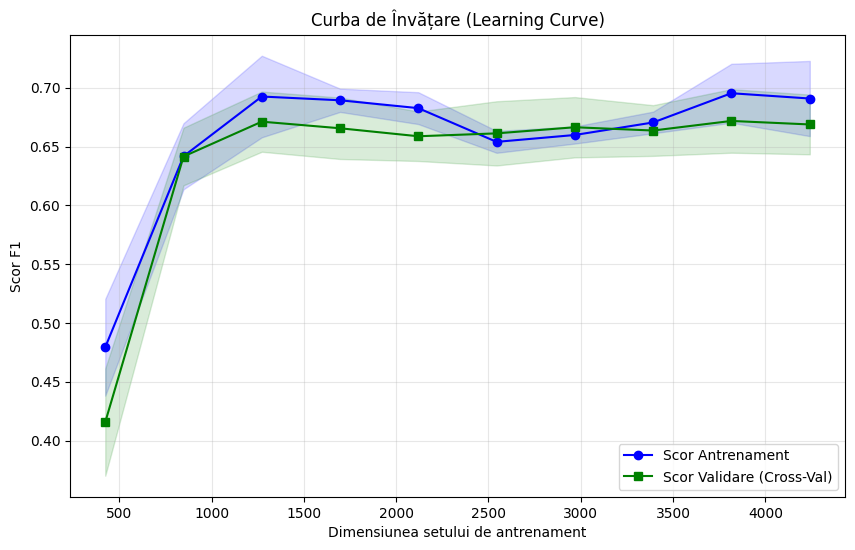

In [73]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    final_model, X_test_prepared, y_test, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Scor Antrenament", color="blue", marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")
plt.plot(train_sizes, test_mean, label="Scor Validare (Cross-Val)", color="green", marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color="green")

plt.title("Curba de Învățare (Learning Curve)")
plt.xlabel("Dimensiunea setului de antrenament")
plt.ylabel("Scor F1")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

Graficul comparativ al metricilor pentru seturile de antrenament și test, utilizând pragul standard de 0.5, confirmă stabilitatea remarcabilă a modelului, diferențele dintre cele două seturi de date fiind neglijabile. Se observă un Recall foarte ridicat (aprox. 0.98), ceea ce demonstrează capacitatea aproape totală a algoritmului de a identifica conflictele reale din cod. Totuși, Precizia modestă (aprox. 0.51) semnalează faptul că, la acest prag implicit, modelul tinde să fie excesiv de precaut, generând un număr ridicat de alerte false pentru a se asigura că nu ratează niciun incident. Această egalitate între performanța de Train și cea de Test atestă o generalizare excelentă, demonstrând că modelul a extras tipare universale și este complet protejat împotriva fenomenului de overfitting.

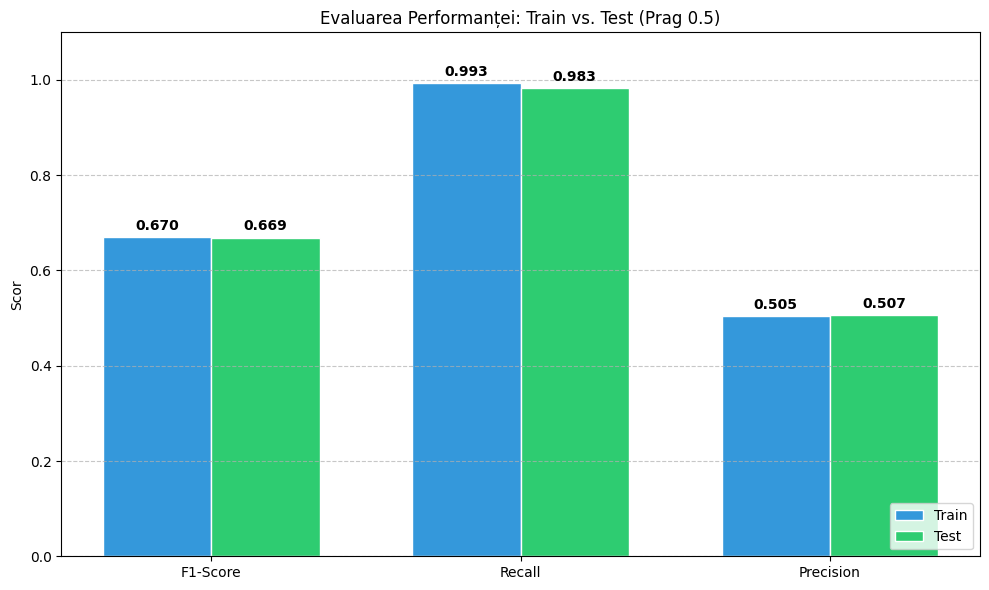

In [70]:
from sklearn.metrics import precision_score, recall_score

y_train_probs = final_model.predict_proba(X_train_prepared)[:, 1]
y_test_probs = final_model.predict_proba(X_test_prepared)[:, 1]

threshold = 0.5
y_train_final = (y_train_probs >= threshold).astype(int)
y_test_final = (y_test_probs >= threshold).astype(int)

metrics = ['F1-Score', 'Recall', 'Precision']
train_vals = [
    f1_score(y_train, y_train_final),
    recall_score(y_train, y_train_final),
    precision_score(y_train, y_train_final)
]
test_vals = [
    f1_score(y_test, y_test_final),
    recall_score(y_test, y_test_final),
    precision_score(y_test, y_test_final)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_vals, width, label='Train', color='#3498db', edgecolor='white')
rects2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#2ecc71', edgecolor='white')

ax.set_ylabel('Scor')
ax.set_title('Evaluarea Performanței: Train vs. Test (Prag 0.5)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## A full pipeline with both preparation and prediction

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

def transform_features(df):
    df = df.copy()

    cols_to_drop = ['commit', 'parent1', 'parent2', 'ancestor', 'copied files']
    df = df.drop(columns=cols_to_drop, errors='ignore')

    df['total_lines_changed'] = df['added lines'] + df['deleted lines']
    df['global_collab_intensity'] = (df['devs parent1'] + df['devs parent2']) * (df['nr commits1'] + df['nr commits2'])
    df['lines_per_file'] = df['total_lines_changed'] / (df['nr files'])
    df['change_velocity'] = df['total_lines_changed'] / (df['time'])
    df['maintenance_work'] = df['fix'] + df['bug']
    df['new_features_work'] = df['feature'] + df['add']
    df['p2_pressure_index'] = df['density2'] * df['devs parent2']
    df['msg_consistency'] = df['messages_mean'] / (df['messages_max'])
    df['branch_activity_diff'] = abs(df['nr commits1'] - df['nr commits2'])
    df['pr_impact_mitigation'] = df['is pr'] * df['total_lines_changed']

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

feature_engineer = FunctionTransformer(transform_features)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])

full_pipeline_with_predictor = Pipeline([
    ("feature_eng", feature_engineer),
    ("preparation", num_pipeline),
    ("classifier", final_model)
])

full_pipeline_with_predictor.fit(X_train, y_train)
final_predictions = full_pipeline_with_predictor.predict(X_test)

print(f"Scorul F1: {f1_score(y_test, final_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

Scorul F1: 0.6690

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      5011
           1       0.51      0.98      0.67       291

    accuracy                           0.95      5302
   macro avg       0.75      0.96      0.82      5302
weighted avg       0.97      0.95      0.95      5302



## Model persistence using joblib

In [72]:
import joblib

joblib.dump(full_pipeline_with_predictor, "my_model.pkl")
model = joblib.load("my_model.pkl")